# Student data processing
Documentation for **student-mat.csv** (Math) and **student-por.csv** (Portuguese). Column meanings are the same in both.

## Grades (course-specific)
| # | Column | Description |
|---|--------|-------------|
| 31 | **G1** | First period grade (0–20) |
| 32 | **G2** | Second period grade (0–20) |
| 33 | **G3** | Final grade (0–20)|

## Student and family attributes
| # | Column | Description |
|---|--------|-------------|
| 1 | **school** | School: `GP` (Gabriel Pereira) or `MS` (Mousinho da Silveira) |
| 2 | **sex** | `F` / `M` |
| 3 | **age** | 15–22 |
| 4 | **address** | Home: `U` (urban) / `R` (rural) |
| 5 | **famsize** | `LE3` (≤3) / `GT3` (>3) |
| 6 | **Pstatus** | Parents: `T` (together) / `A` (apart) |
| 7 | **Medu** | Mother’s education: 0 none, 1 primary (4th), 2 5th–9th, 3 secondary, 4 higher |
| 8 | **Fedu** | Father’s education (same coding as **Medu**) |
| 9 | **Mjob** | Mother’s job: `teacher`, `health`, `services`, `at_home`, `other` |
| 10 | **Fjob** | Father’s job (same categories as **Mjob**) |
| 11 | **reason** | School choice: `home`, `reputation`, `course`, `other` |
| 12 | **guardian** | `mother`, `father`, `other` |
| 13 | **traveltime** | Home–school: 1 &lt;15 min, 2 15–30 min, 3 30 min–1 h, 4 &gt;1 h |
| 14 | **studytime** | Weekly study: 1 &lt;2 h, 2 2–5 h, 3 5–10 h, 4 &gt;10 h |
| 15 | **failures** | Past class failures: *n* if 1 ≤ *n* &lt; 3, else 4 |

## School support and lifestyle
| # | Column | Description |
|---|--------|-------------|
| 16 | **schoolsup** | Extra educational support: yes / no |
| 17 | **famsup** | Family educational support: yes / no |
| 18 | **paid** | Extra paid classes in this subject (Math or Portuguese): yes / no |
| 19 | **activities** | Extra-curricular activities: yes / no |
| 20 | **nursery** | Attended nursery: yes / no |
| 21 | **higher** | Wants higher education: yes / no |
| 22 | **internet** | Internet at home: yes / no |
| 23 | **romantic** | In a romantic relationship: yes / no |
| 24 | **famrel** | Family relationships: 1 (very bad)–5 (excellent) |
| 25 | **freetime** | Free time after school: 1–5 |
| 26 | **goout** | Going out with friends: 1–5 |
| 27 | **Dalc** | Weekday alcohol: 1–5 |
| 28 | **Walc** | Weekend alcohol: 1–5 |
| 29 | **health** | Health: 1 (very bad)–5 (very good) |
| 30 | **absences** | Number of absences (0–93) |

In [1]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
%matplotlib inline
import seaborn

In [2]:
mathematics_dataset = pd.read_csv('./data/student-mat.csv', sep=';')
portuguese_dataset = pd.read_csv('./data/student-por.csv', sep=';')

# Print the shape of the datasets
print(mathematics_dataset.shape)
print(portuguese_dataset.shape)

# Print the columns of the datasets
print(mathematics_dataset.columns)
print(portuguese_dataset.columns)

(395, 33)
(649, 33)
Index(['school', 'sex', 'age', 'address', 'famsize', 'Pstatus', 'Medu', 'Fedu',
       'Mjob', 'Fjob', 'reason', 'guardian', 'traveltime', 'studytime',
       'failures', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery',
       'higher', 'internet', 'romantic', 'famrel', 'freetime', 'goout', 'Dalc',
       'Walc', 'health', 'absences', 'G1', 'G2', 'G3'],
      dtype='str')
Index(['school', 'sex', 'age', 'address', 'famsize', 'Pstatus', 'Medu', 'Fedu',
       'Mjob', 'Fjob', 'reason', 'guardian', 'traveltime', 'studytime',
       'failures', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery',
       'higher', 'internet', 'romantic', 'famrel', 'freetime', 'goout', 'Dalc',
       'Walc', 'health', 'absences', 'G1', 'G2', 'G3'],
      dtype='str')


In [3]:

# Missing data inside the dataset
print(mathematics_dataset.isna().sum())
print(portuguese_dataset.isna().sum())

school        0
sex           0
age           0
address       0
famsize       0
Pstatus       0
Medu          0
Fedu          0
Mjob          0
Fjob          0
reason        0
guardian      0
traveltime    0
studytime     0
failures      0
schoolsup     0
famsup        0
paid          0
activities    0
nursery       0
higher        0
internet      0
romantic      0
famrel        0
freetime      0
goout         0
Dalc          0
Walc          0
health        0
absences      0
G1            0
G2            0
G3            0
dtype: int64
school        0
sex           0
age           0
address       0
famsize       0
Pstatus       0
Medu          0
Fedu          0
Mjob          0
Fjob          0
reason        0
guardian      0
traveltime    0
studytime     0
failures      0
schoolsup     0
famsup        0
paid          0
activities    0
nursery       0
higher        0
internet      0
romantic      0
famrel        0
freetime      0
goout         0
Dalc          0
Walc          0
health     

# Exploratory Data Analysis

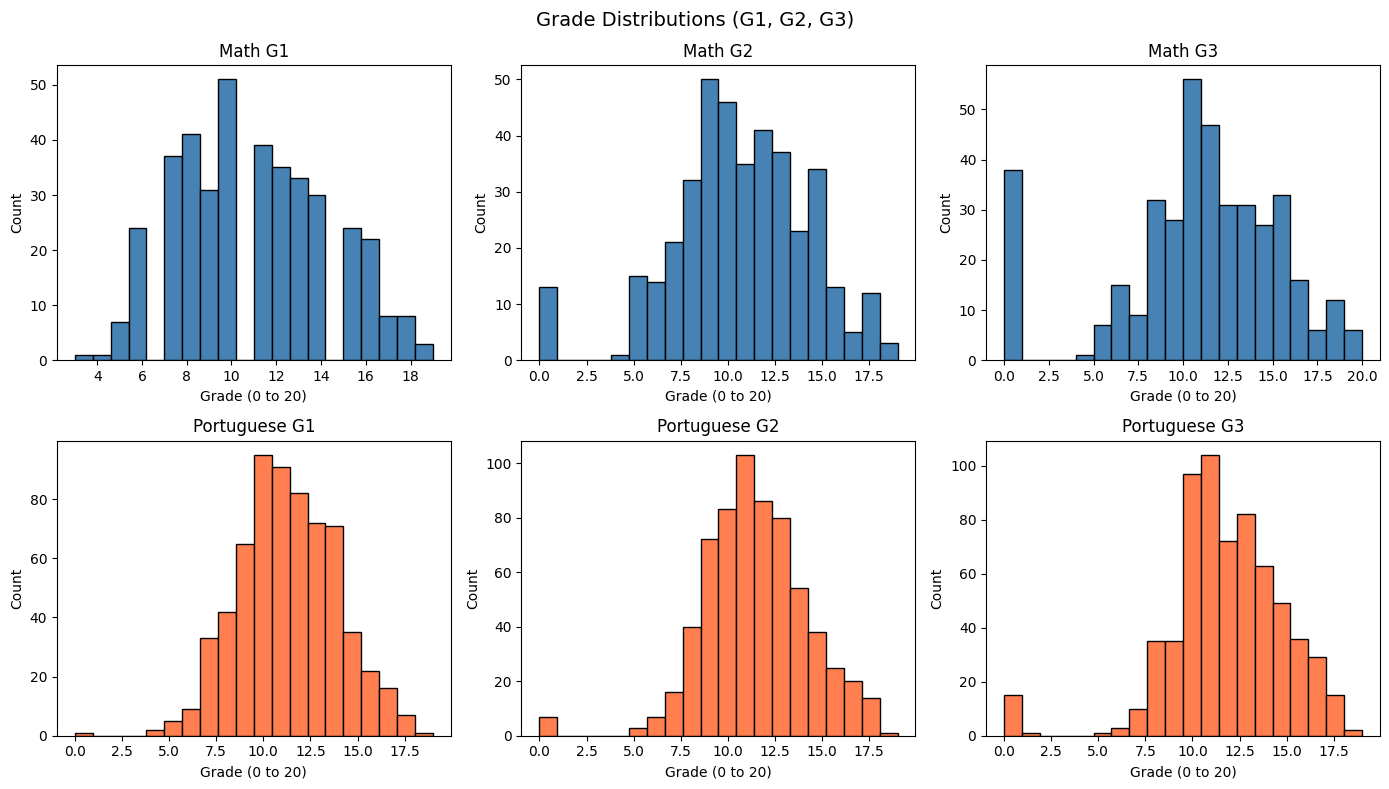

In [4]:
import seaborn as sns

# Grade distributions for both datasets
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
fig.suptitle('Grade Distributions (G1, G2, G3)', fontsize=14)

for i, grade in enumerate(['G1', 'G2', 'G3']):
    axes[0, i].hist(mathematics_dataset[grade], bins=20, color='steelblue', edgecolor='black')
    axes[0, i].set_title(f'Math {grade}')
    axes[0, i].set_xlabel('Grade (0 to 20)')
    axes[0, i].set_ylabel('Count')

    axes[1, i].hist(portuguese_dataset[grade], bins=20, color='coral', edgecolor='black')
    axes[1, i].set_title(f'Portuguese {grade}')
    axes[1, i].set_xlabel('Grade (0 to 20)')
    axes[1, i].set_ylabel('Count')

plt.tight_layout()
plt.show()

### Correlation Heatmap
Which numeric features are most correlated with the final grade G3?

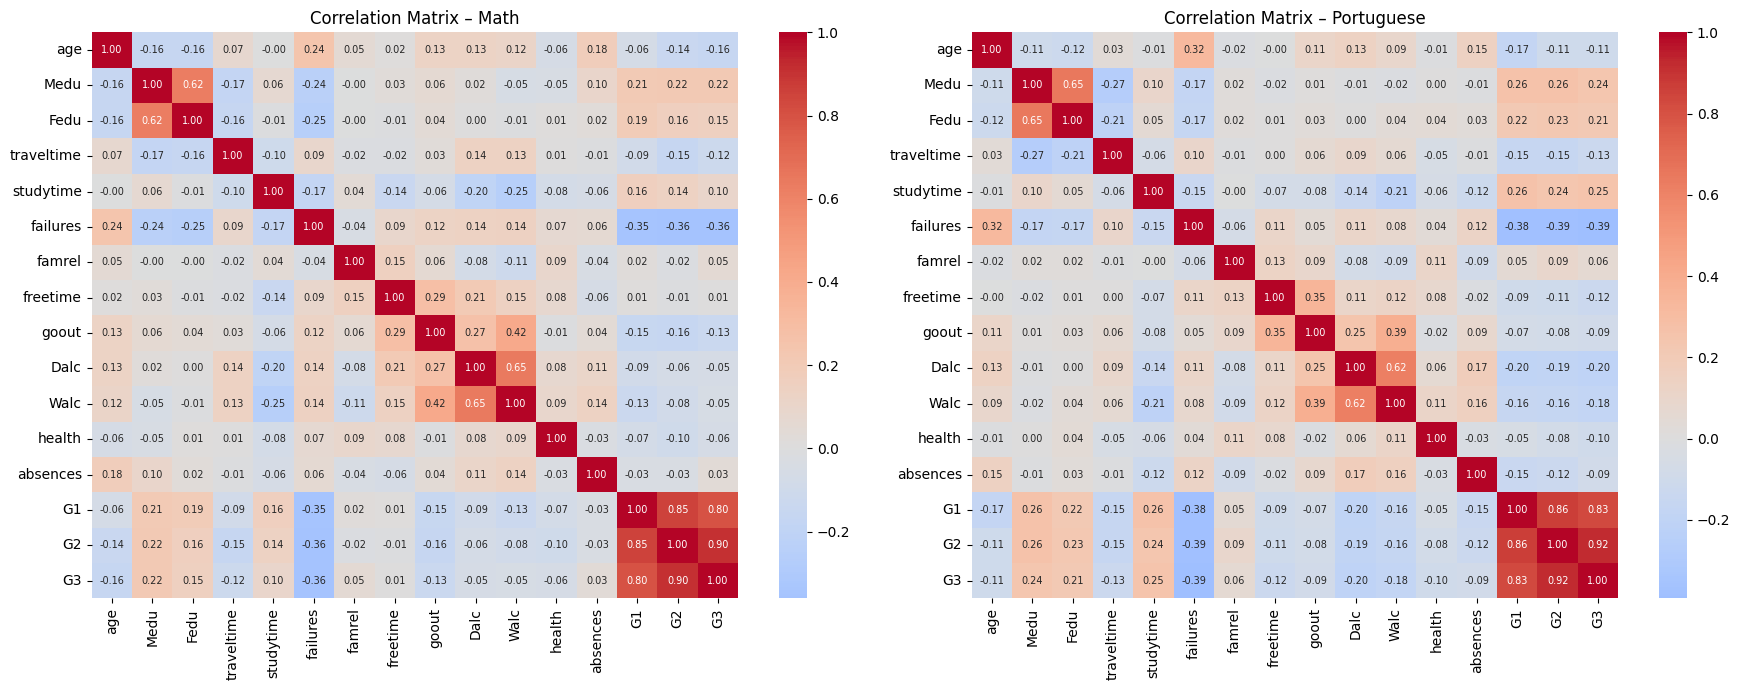

In [5]:
numeric_cols = ['age', 'Medu', 'Fedu', 'traveltime', 'studytime', 'failures',
                'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences', 'G1', 'G2', 'G3']

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

for ax, dataset, title in zip(axes, [mathematics_dataset, portuguese_dataset], ['Math', 'Portuguese']):
    corr = dataset[numeric_cols].corr()
    sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
                annot_kws={'size': 7}, ax=ax)
    ax.set_title(f'Correlation Matrix – {title}')

plt.tight_layout()
plt.show()

### Categorical Analysis
How do key categorical variables relate to G3?

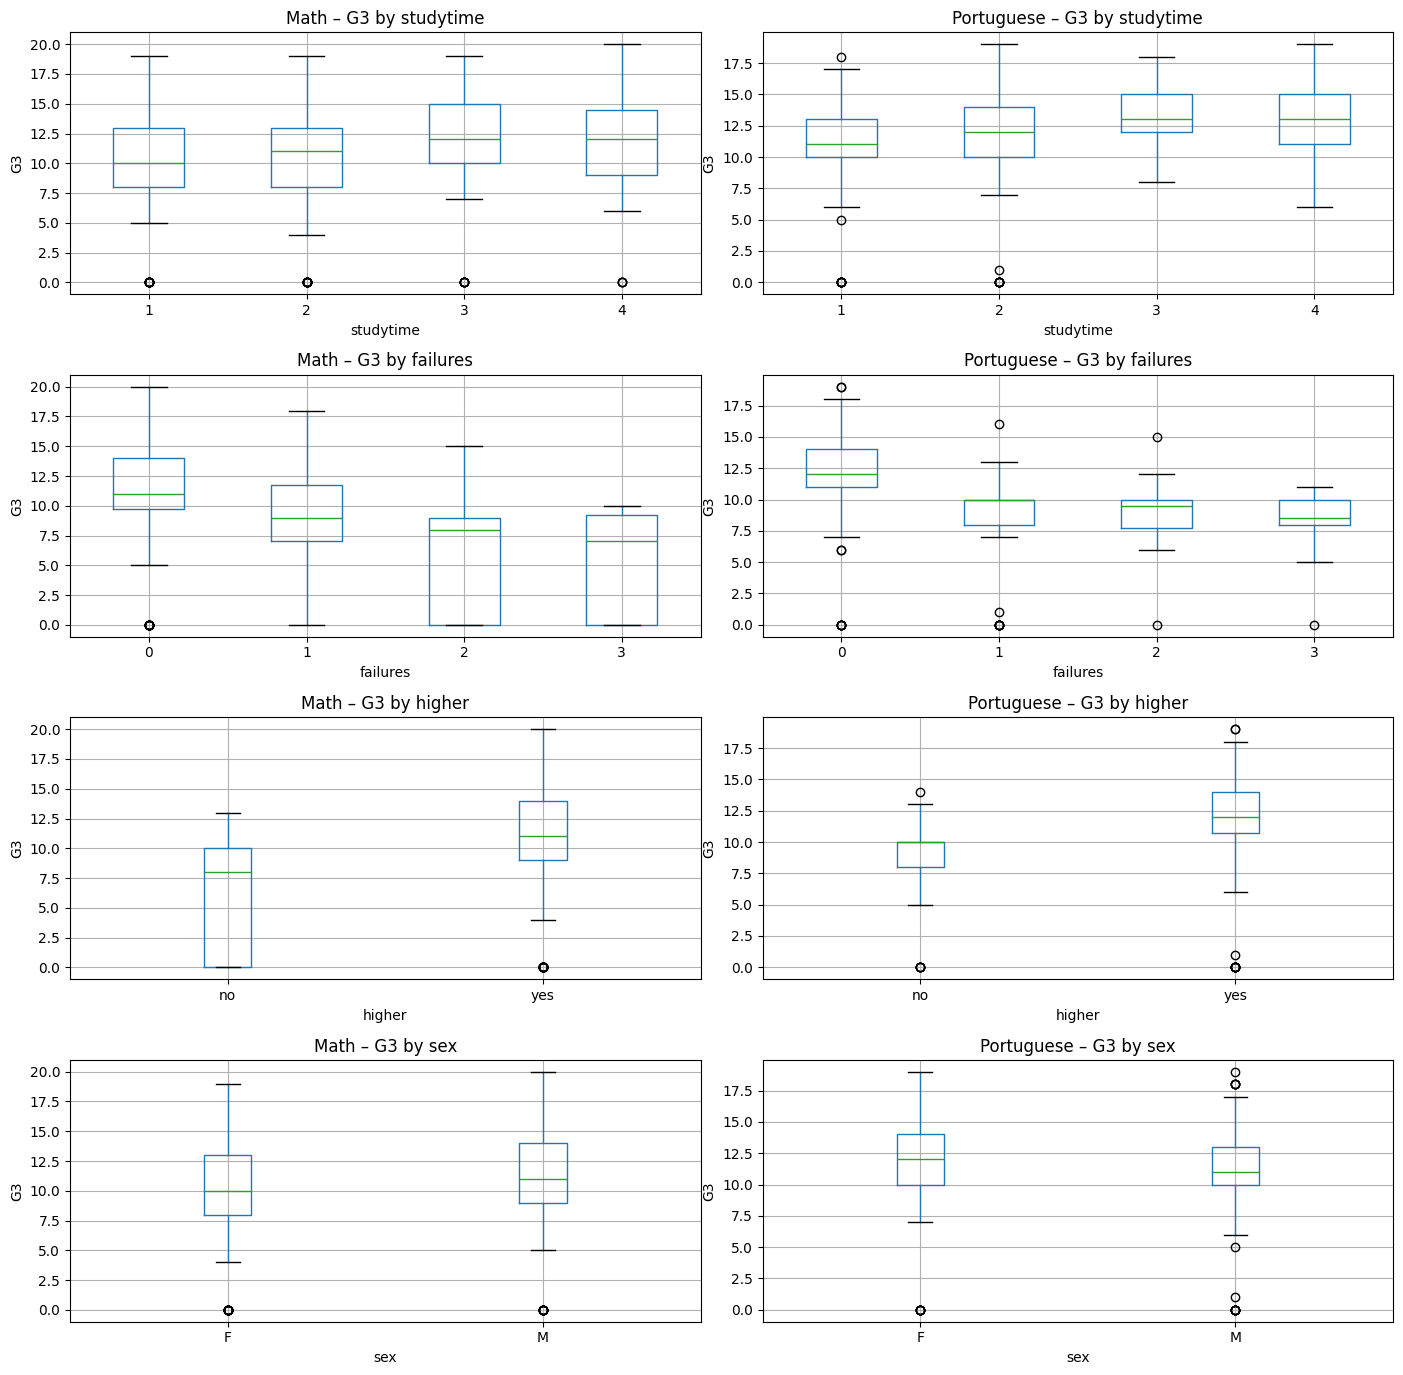

In [6]:
cat_vars = ['studytime', 'failures', 'higher', 'sex']
cat_labels = {
    'studytime': ['<2h', '2–5h', '5–10h', '>10h'],
    'failures':  ['0', '1', '2', '3+'],
    'higher':    ['no', 'yes'],
    'sex':       ['F', 'M'],
}

fig, axes = plt.subplots(len(cat_vars), 2, figsize=(14, 14))
fig.suptitle('G3 by Categorical Variables', fontsize=14)

for row, var in enumerate(cat_vars):
    for col, (dataset, title) in enumerate([(mathematics_dataset, 'Math'), (portuguese_dataset, 'Portuguese')]):
        ax = axes[row, col]
        dataset.boxplot(column='G3', by=var, ax=ax)
        ax.set_title(f'{title} – G3 by {var}')
        ax.set_xlabel(var)
        ax.set_ylabel('G3')
        plt.sca(ax)
        plt.title(f'{title} – G3 by {var}')

plt.suptitle('')  # remove auto-generated suptitle from boxplot
plt.tight_layout()
plt.show()

### Absences
The `absences` variable ranges 0–93 in the dataset. Let's check its distribution.

Math:
count    395.000000
mean       5.708861
std        8.003096
min        0.000000
25%        0.000000
50%        4.000000
75%        8.000000
max       75.000000
Name: absences, dtype: float64

Portuguese:
count    649.000000
mean       3.659476
std        4.640759
min        0.000000
25%        0.000000
50%        2.000000
75%        6.000000
max       32.000000
Name: absences, dtype: float64



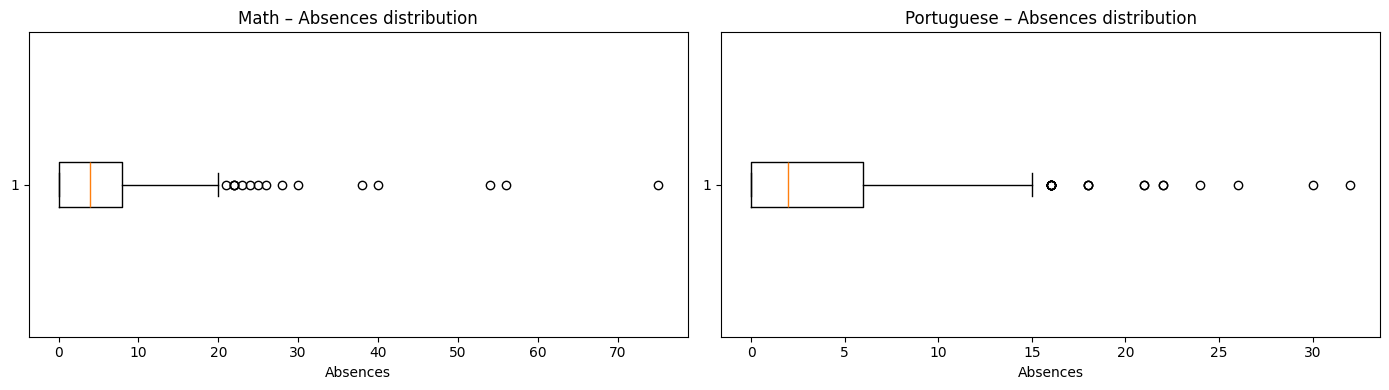

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for ax, dataset, title in zip(axes, [mathematics_dataset, portuguese_dataset], ['Math', 'Portuguese']):
    ax.boxplot(dataset['absences'], vert=False)
    ax.set_title(f'{title} – Absences distribution')
    ax.set_xlabel('Absences')
    stats = dataset['absences'].describe()
    print(f"{title}:\n{stats}\n")

plt.tight_layout()
plt.show()

### Pass / Fail Balance
We define **pass** as G3 ≥ 10. This is the target for the classification task.

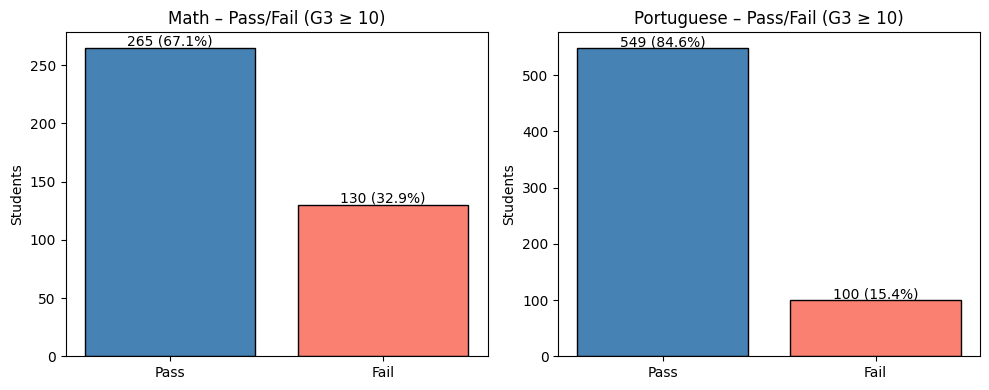

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

for ax, dataset, title in zip(axes, [mathematics_dataset, portuguese_dataset], ['Math', 'Portuguese']):
    counts = (dataset['G3'] >= 10).value_counts().rename({True: 'Pass', False: 'Fail'})
    ax.bar(counts.index, counts.values, color=['steelblue', 'salmon'], edgecolor='black')
    ax.set_title(f'{title} – Pass/Fail (G3 ≥ 10)')
    ax.set_ylabel('Students')
    for i, v in enumerate(counts.values):
        ax.text(i, v + 2, f'{v} ({v/len(dataset)*100:.1f}%)', ha='center')

plt.tight_layout()
plt.show()